In [1]:
import pandas as pd

In [2]:
%pwd
%cd /home/jovyan/work/COVID/parameter_tuning/binary/Cell/
%pwd

/home/jovyan/work/COVID/parameter_tuning/binary/Cell


'/home/jovyan/work/COVID/parameter_tuning/binary/Cell'

In [3]:
# import the distance data
distance_ctrl = pd.read_csv("distance_ctrl.csv", index_col=0)

# distance_NA = pd.read_csv("distance_NA.csv", index_col=0)
distance_ctrl

,AL627309.1,AL627309.4,AL732372.1,AL669831.2,AL669831.5,LINC00115,FAM41C,AL645608.7,AL645608.3,AL645608.5,...,AL592183.1,AC007325.1,AC007325.4,AC007325.2,AL354822.1,AC023491.2,AC004556.1,AC233755.2,AC233755.1,AC240274.1
AL627309.1,0.0,3.0,3.0,3.0,3.0,3.0,6.0,4.0,2.0,2.0,...,5.0,4.0,5.0,3.0,3.0,4.0,6.0,4.0,4.0,5.0
AL627309.4,3.0,0.0,4.0,2.0,2.0,2.0,5.0,3.0,1.0,1.0,...,4.0,4.0,5.0,4.0,2.0,5.0,5.0,4.0,4.0,4.0
AL732372.1,3.0,4.0,0.0,4.0,4.0,4.0,4.0,2.0,4.0,3.0,...,4.0,4.0,4.0,2.0,3.0,4.0,6.0,2.0,2.0,4.0
AL669831.2,3.0,2.0,4.0,0.0,3.0,3.0,5.0,3.0,2.0,2.0,...,5.0,4.0,4.0,4.0,2.0,5.0,6.0,4.0,4.0,5.0
AL669831.5,3.0,2.0,4.0,3.0,0.0,1.0,5.0,3.0,2.0,2.0,...,4.0,4.0,5.0,4.0,3.0,5.0,6.0,4.0,4.0,3.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
AC023491.2,4.0,5.0,4.0,5.0,5.0,4.0,5.0,4.0,4.0,4.0,...,5.0,3.0,5.0,4.0,4.0,0.0,7.0,5.0,5.0,5.0
AC004556.1,6.0,5.0,6.0,6.0,6.0,5.0,4.0,5.0,5.0,5.0,...,6.0,6.0,6.0,5.0,5.0,7.0,0.0,6.0,7.0,4.0
AC233755.2,4.0,4.0,2.0,4.0,4.0,3.0,5.0,3.0,3.0,3.0,...,4.0,4.0,4.0,3.0,3.0,5.0,6.0,0.0,2.0,3.0
AC233755.1,4.0,4.0,2.0,4.0,4.0,4.0,5.0,3.0,4.0,4.0,...,5.0,5.0,4.0,3.0,3.0,5.0,7.0,2.0,0.0,4.0


In [4]:
# Set the name of the DataFrame
distance_ctrl.name = "distance_ctrl"
# distance_NA.name = "distance_NA"

construct a weighted graph as leiden's input from the 50-PC distance space. Using Euclidean distance in the space, selecting top k% shortest distance as edges, normalize the distance to between 0-1, and then take the reciprocal to make smaller distances larger weights and vice versa

In [5]:
import sys
sys.path.append('/home/jovyan/work/FUNCTIONS/')
from methods import distance_to_module_nlog, module_to_json

In [6]:
%pwd
%cd /home/jovyan/work/COVID/parameter_tuning/binary/knd_nlog/Cell/
%pwd

/home/jovyan/work/COVID/parameter_tuning/binary/knd_nlog/Cell


'/home/jovyan/work/COVID/parameter_tuning/binary/knd_nlog/Cell'

Cell: resolution = 0.3

threshold_percentile = 30%: threshold_distance = 158.56544390250986
Number of connected components: 1


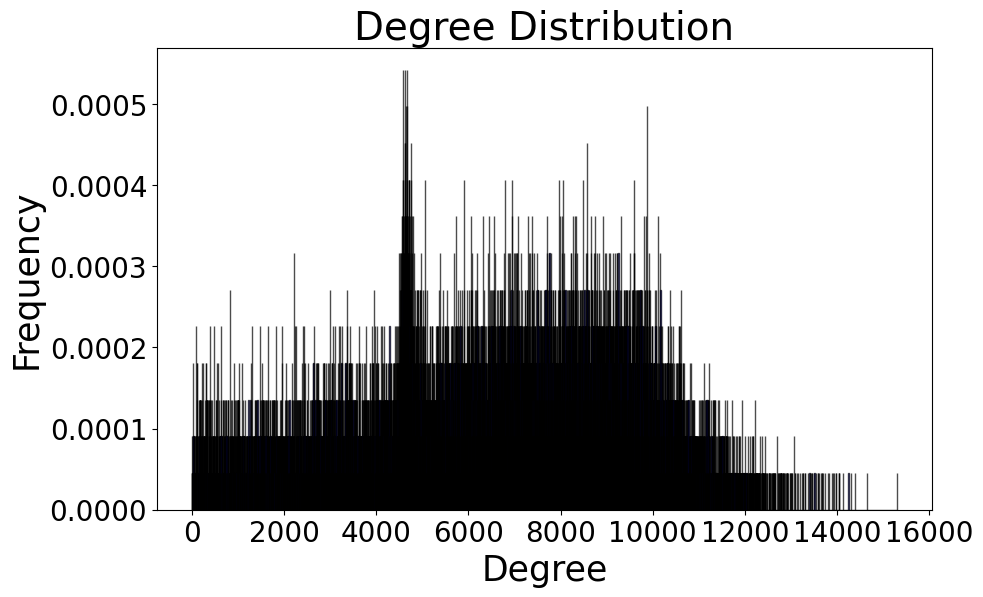

Number of clusters: 36
Cluster assignments: [0, 0, 2, 0, 0, 0, 4, 1, 0, 0, 1, 4, 0, 0, 2, 6, 3, 10, 0, 6]
Number of modules: 31
threshold_percentile = 30%: threshold_distance = 158.56544390250986
Number of connected components: 1


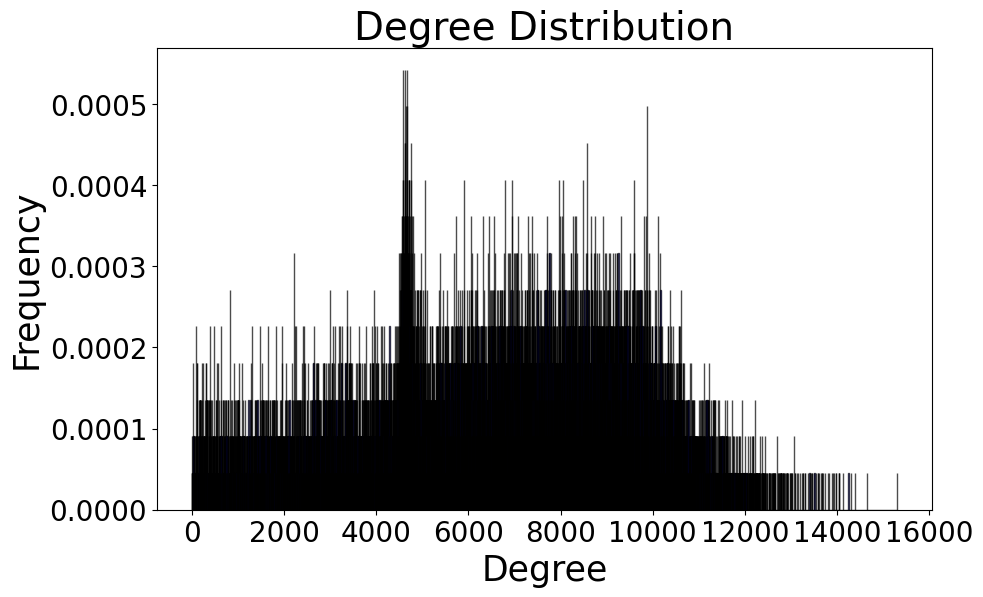

Number of clusters: 55
Cluster assignments: [0, 0, 2, 0, 0, 0, 9, 1, 0, 0, 1, 4, 0, 0, 2, 5, 5, 11, 0, 6]
Number of modules: 42
threshold_percentile = 30%: threshold_distance = 158.56544390250986
Number of connected components: 1


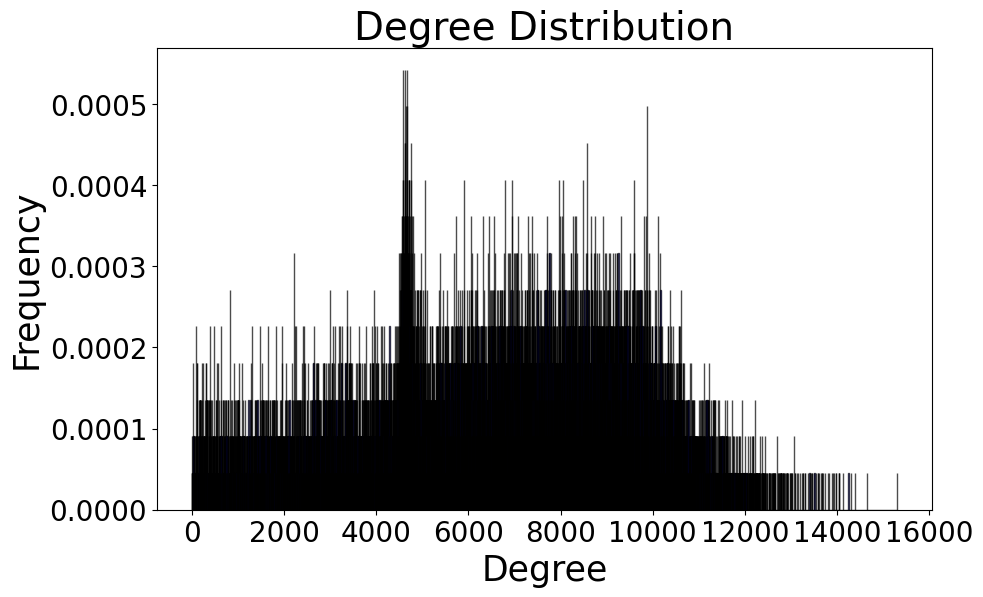

Number of clusters: 81
Cluster assignments: [0, 0, 2, 0, 0, 0, 11, 1, 0, 0, 1, 5, 0, 0, 2, 7, 3, 12, 0, 6]
Number of modules: 60
threshold_percentile = 30%: threshold_distance = 158.56544390250986
Number of connected components: 1


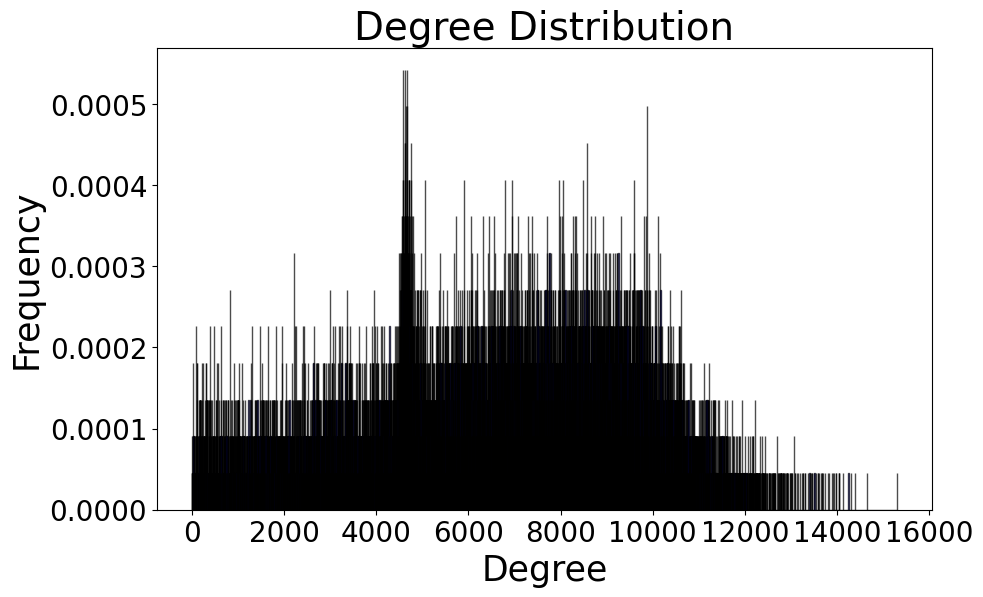

Number of clusters: 116
Cluster assignments: [21, 0, 2, 0, 0, 0, 12, 1, 0, 0, 1, 6, 0, 0, 7, 7, 3, 36, 0, 7]
Number of modules: 83
threshold_percentile = 30%: threshold_distance = 158.56544390250986
Number of connected components: 1


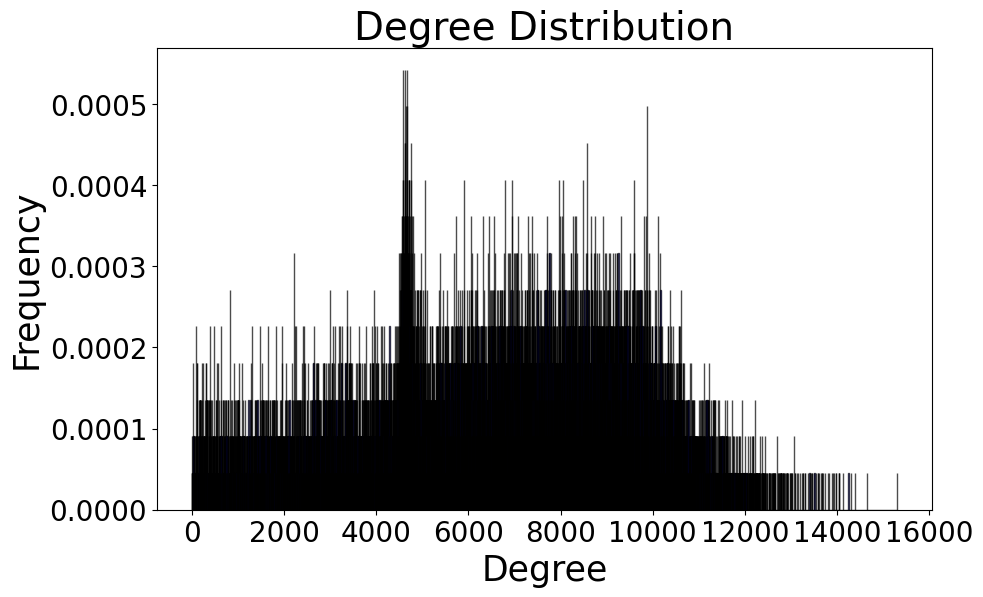

In [ ]:
resolution_values = [0.1,0.15,0.2,0.25,0.3,0.35,0.4,0.45,0.5]  # for 30%: ~ modules
# resolution_values = [0.1,0.15,0.2,0.25,0.3,0.35,0.4,0.45,0.5]  # for 40%: 25~445 modules
# resolution_values = [0.1,0.15,0.2,0.25,0.3,0.35,0.4,0.45,0.5]  # for 45%: 15~375 modules
# resolution_values = [0.1,0.15,0.2,0.25,0.3,0.35,0.4,0.45,0.5]  # for 50%: 15~310 modules

# cannot calculate distance since it takes too long for a denser graph
for resolution_parameter in resolution_values:
    module_ctrl = distance_to_module_nlog(distance_coordinate=distance_ctrl, fig_path1=f"./figures/degree_distribution_ctrl_{resolution_parameter}.png", fig_path2=f"./figures/weight_distribution_ctrl_{resolution_parameter}.png", threshold_percentile=30, resolution_parameter=resolution_parameter, seed=123456)
    module_to_json(module_dict=module_ctrl, file_path=f"module_ctrl_{resolution_parameter}.json")

In [ ]:
del module_ctrl
del distance_ctrl

In [ ]:
%pwd
%cd /home/jovyan/work/COVID/parameter_tuning/binary/Cell/
%pwd

distance_mild = pd.read_csv("distance_mild.csv", index_col=0)
distance_mild.name = "distance_mild"

In [10]:
%pwd
%cd /home/jovyan/work/COVID/parameter_tuning/binary/knd_nlog/Cell/
%pwd

for resolution_parameter in resolution_values:
    module_mild = distance_to_module_nlog(distance_coordinate=distance_mild, fig_path1=f"./figures/degree_distribution_mild_{resolution_parameter}.png", fig_path2=f"./figures/weight_distribution_mild_{resolution_parameter}.png", threshold_percentile=30, resolution_parameter=resolution_parameter, seed=123456)
    module_to_json(module_dict=module_mild, file_path=f"module_mild_{resolution_parameter}.json")

Number of clusters: 443
Cluster assignments: [14, 9, 26, 9, 35, 7, 28, 0, 3, 1, 26, 60, 54, 133, 11, 29, 11, 4, 11, 2]
Number of modules: 247


In [11]:
del module_mild
del distance_mild

In [12]:
%pwd
%cd /home/jovyan/work/COVID/parameter_tuning/binary/Cell/
%pwd

distance_severe = pd.read_csv("distance_severe.csv", index_col=0)
distance_severe.name = "distance_severe"

/home/jovyan/work/COVID/parameter_tuning/binary/Cell


/home/jovyan/work/COVID/parameter_tuning/binary/knd_nlog/Cell
threshold_percentile = 30%: threshold_distance = 201.10693672770216
Number of connected components: 1


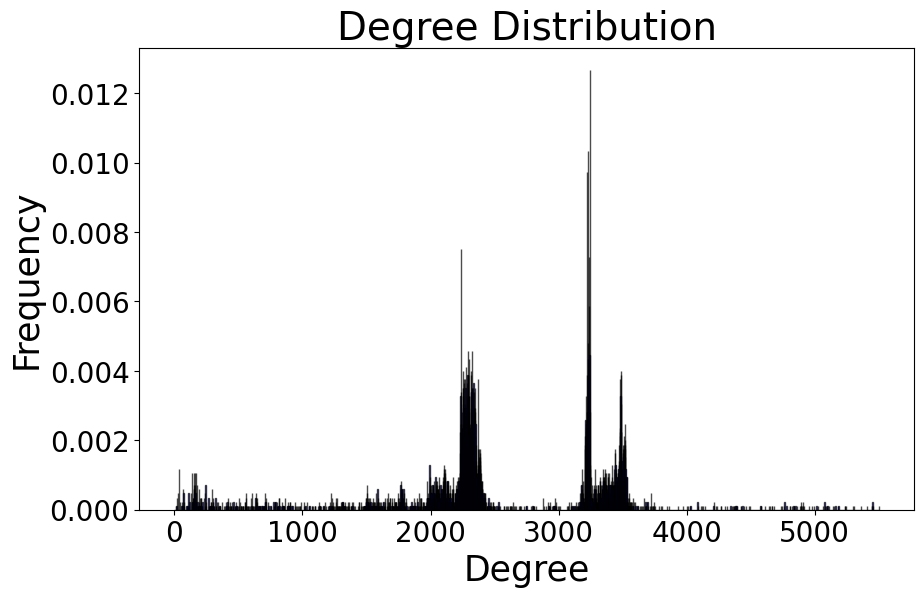

Number of clusters: 12
Cluster assignments: [2, 2, 0, 2, 1, 1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 2]
Number of modules: 9
threshold_percentile = 30%: threshold_distance = 201.10693672770216
Number of connected components: 1


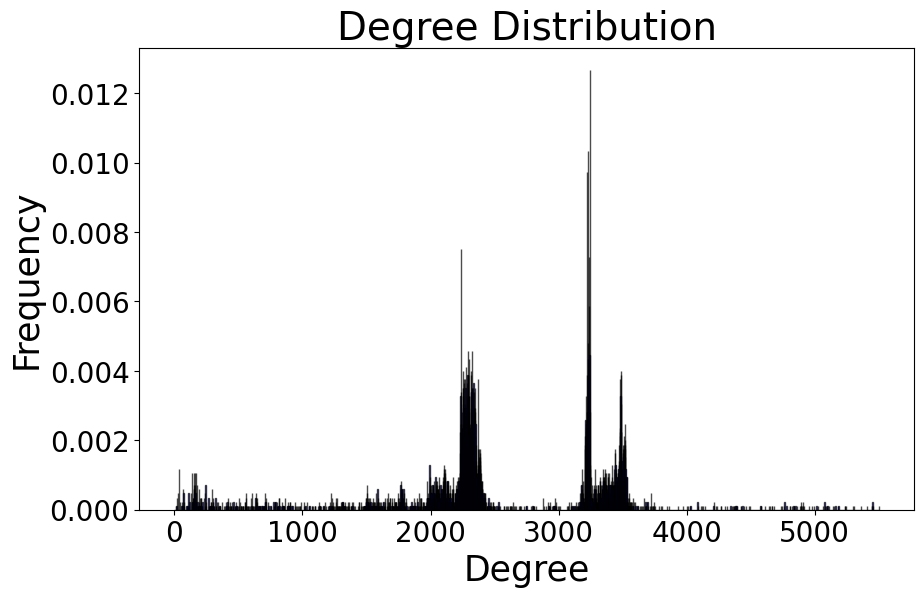

Number of clusters: 13
Cluster assignments: [2, 2, 3, 2, 1, 1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 2]
Number of modules: 11
threshold_percentile = 30%: threshold_distance = 201.10693672770216
Number of connected components: 1


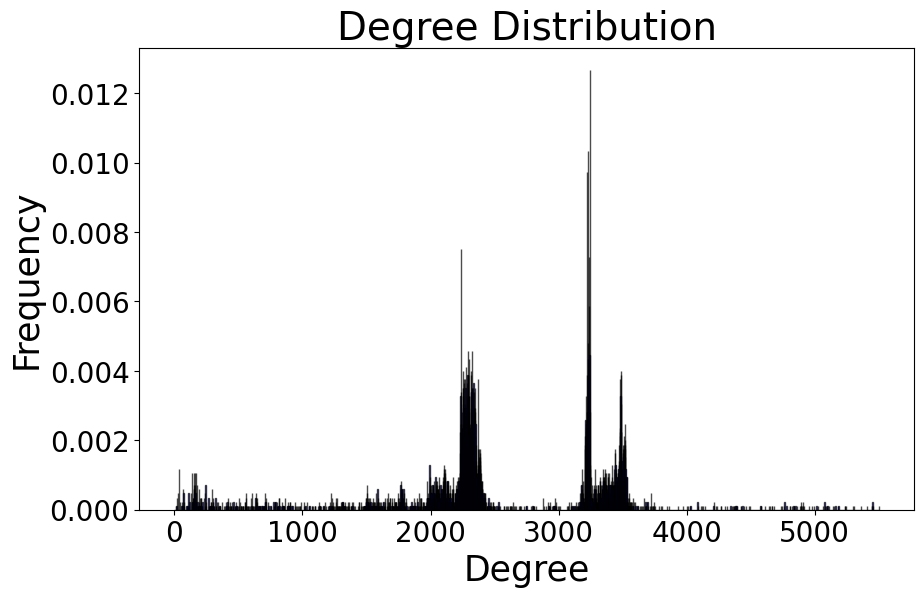

Number of clusters: 15
Cluster assignments: [1, 1, 4, 1, 3, 2, 2, 0, 2, 2, 2, 2, 0, 0, 2, 2, 2, 2, 0, 1]
Number of modules: 12
threshold_percentile = 30%: threshold_distance = 201.10693672770216
Number of connected components: 1


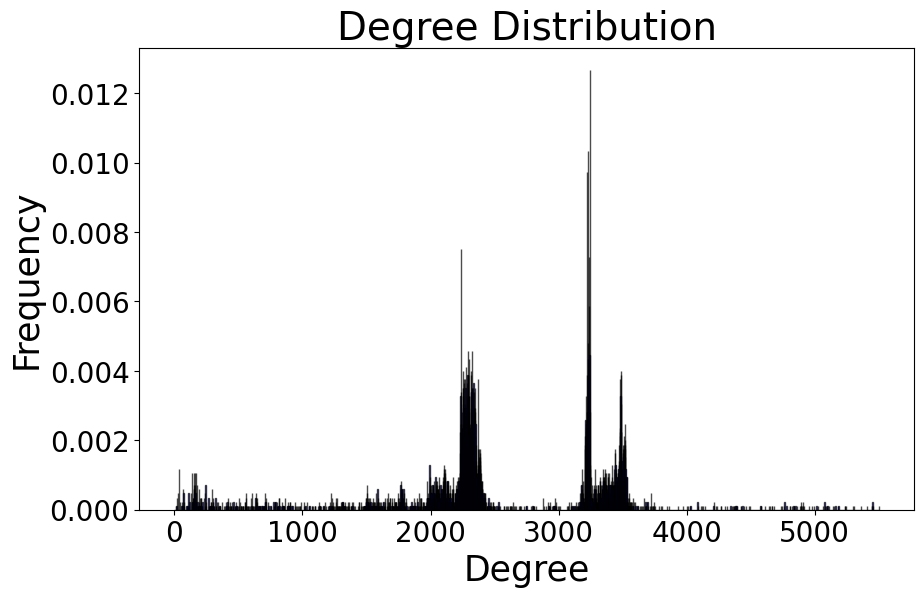

Number of clusters: 16
Cluster assignments: [1, 1, 4, 1, 3, 2, 2, 0, 2, 2, 2, 2, 0, 0, 2, 2, 2, 2, 0, 1]
Number of modules: 14
threshold_percentile = 30%: threshold_distance = 201.10693672770216
Number of connected components: 1


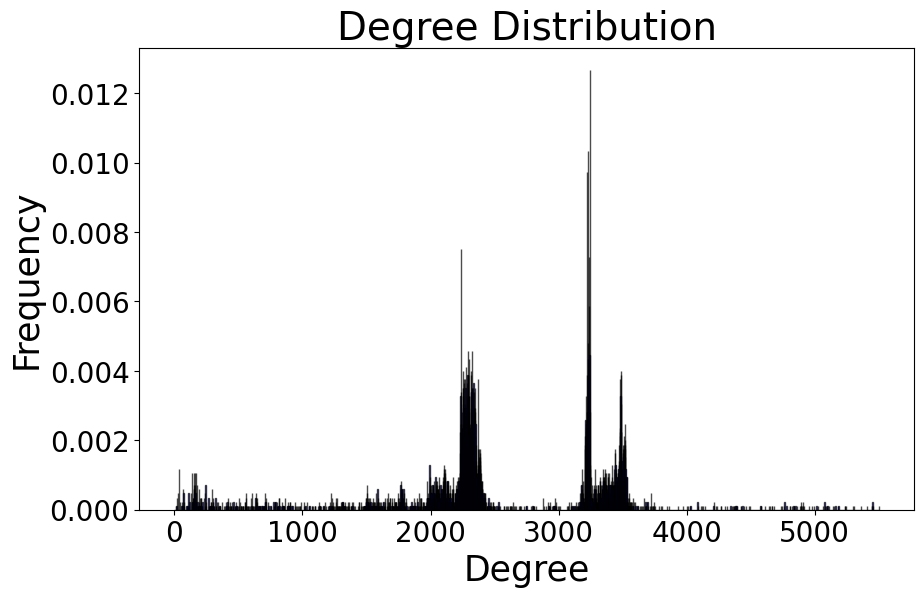

Number of clusters: 19
Cluster assignments: [1, 1, 3, 1, 4, 2, 2, 3, 2, 2, 2, 2, 0, 0, 2, 2, 2, 2, 0, 1]
Number of modules: 17
threshold_percentile = 30%: threshold_distance = 201.10693672770216
Number of connected components: 1


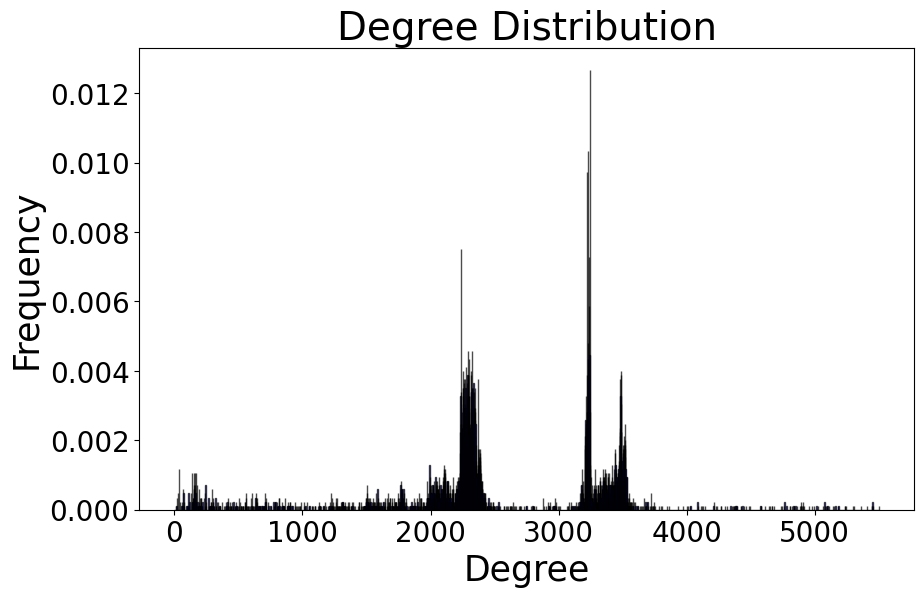

Number of clusters: 21
Cluster assignments: [1, 1, 3, 1, 4, 2, 6, 3, 2, 2, 2, 2, 0, 0, 2, 2, 2, 2, 0, 1]
Number of modules: 17
threshold_percentile = 30%: threshold_distance = 201.10693672770216
Number of connected components: 1


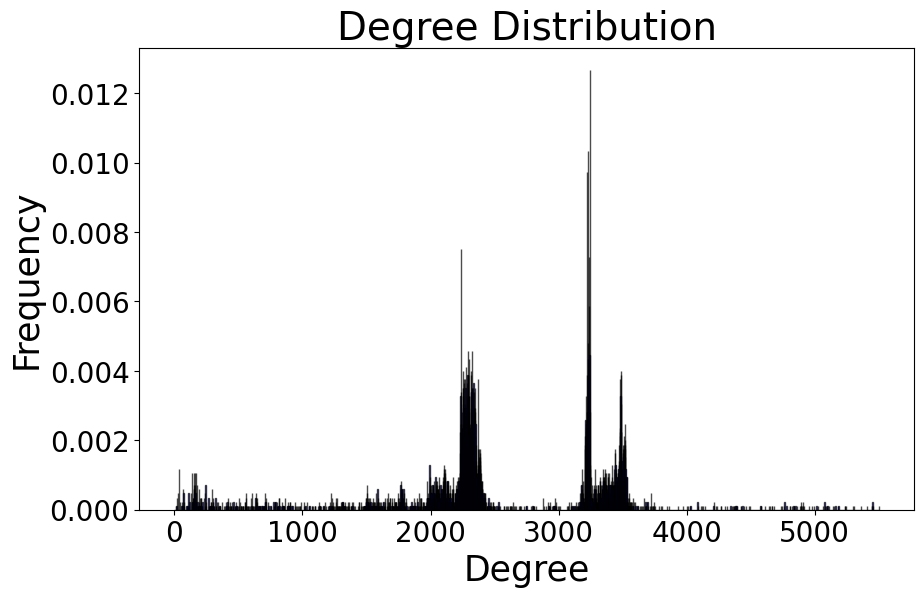

Number of clusters: 26
Cluster assignments: [1, 1, 3, 1, 4, 2, 6, 3, 2, 2, 2, 2, 0, 0, 2, 2, 2, 2, 0, 1]
Number of modules: 19
threshold_percentile = 30%: threshold_distance = 201.10693672770216
Number of connected components: 1


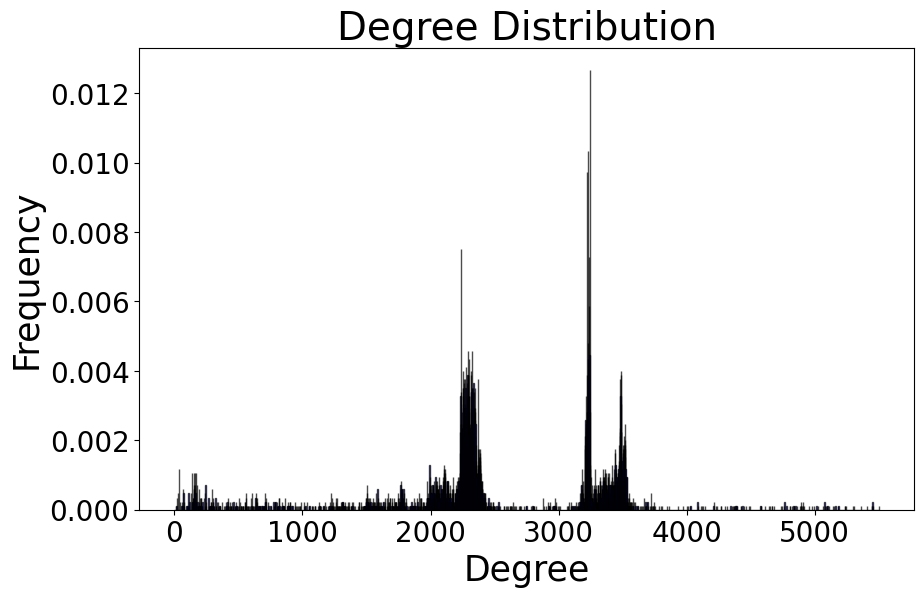

Number of clusters: 27
Cluster assignments: [1, 1, 3, 1, 5, 2, 4, 3, 2, 2, 2, 2, 0, 0, 2, 2, 2, 4, 0, 1]
Number of modules: 23
threshold_percentile = 30%: threshold_distance = 201.10693672770216
Number of connected components: 1


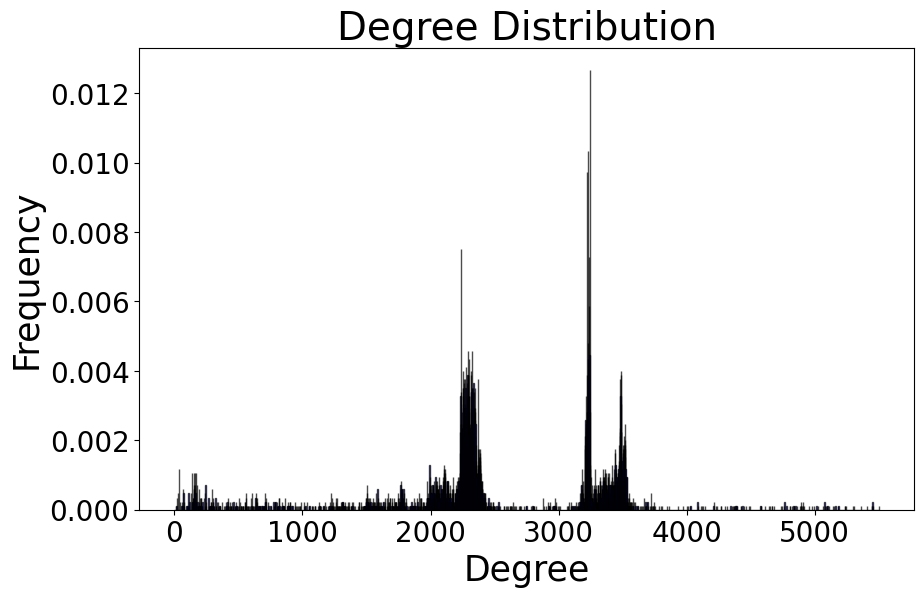

Number of clusters: 30
Cluster assignments: [1, 1, 3, 1, 5, 4, 4, 3, 2, 2, 2, 2, 0, 0, 2, 2, 2, 4, 0, 1]
Number of modules: 23


In [13]:
%pwd
%cd /home/jovyan/work/COVID/parameter_tuning/binary/knd_nlog/Cell/
%pwd

for resolution_parameter in resolution_values:
    module_severe = distance_to_module_nlog(distance_coordinate=distance_severe, fig_path1=f"./figures/degree_distribution_severe_{resolution_parameter}.png", fig_path2=f"./figures/weight_distribution_severe_{resolution_parameter}.png", threshold_percentile=30, resolution_parameter=resolution_parameter, seed=123456)
    module_to_json(module_dict=module_severe, file_path=f"module_severe_{resolution_parameter}.json")

In [14]:
del module_severe
del distance_severe